# Actividad 5 — Optimización de un modelo de ensamble

Selección de características y ajuste de hiperparámetros de un **Random Forest** para detectar tumores malignos en el dataset **Breast Cancer Wisconsin (Diagnostic)**.

**Autor:** Gael Rodríguez Jiménez

## Índice
0. Planteamiento del problema
1. Importar librerías
2. Cargar los datos
3. Revisión de calidad de los datos
4. Separar entrenamiento y prueba
5. Modelo base
6. Análisis de variables redundantes
7. Selección de características con `SelectFromModel`
8. Comparación: modelo base vs modelo reducido
9. Ajuste de hiperparámetros con `GridSearchCV`
10. Modelo optimizado y comparación de los tres modelos
11. Visualizaciones comparativas
12. Análisis: ¿vale la pena la mejora?
13. Conclusión

> Cada celda de código va seguida de una explicación **«¿Qué hace este código?»**, línea por línea.

## 0. Planteamiento del problema

| Campo | Detalle |
|---|---|
| **Dataset** | Breast Cancer Wisconsin (Diagnostic) |
| **Autores** | W. H. Wolberg, W. N. Street y O. L. Mangasarian, Universidad de Wisconsin |
| **Fuente** | [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), incluido en scikit-learn como [`load_breast_cancer`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) |
| **Licencia** | CC BY 4.0 |
| **Volumen** | 569 observaciones × 30 variables numéricas |
| **Tipo de problema** | Clasificación binaria |

> Wolberg, W., Mangasarian, O., Street, N. y Street, W. (1995). *Breast Cancer Wisconsin (Diagnostic)* [Conjunto de datos]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B

Es el mismo dataset de la Actividad 3, lo cual está permitido por las instrucciones. Se eligió porque es un caso ideal para **selección de características**: sus 30 variables son en realidad 10 medidas repetidas tres veces (media, error estándar y peor valor), y varias son casi idénticas entre sí (por ejemplo, el radio, el perímetro y el área de un núcleo celular).

**¿Qué representa cada observación?** Una biopsia por aspiración con aguja fina (FNA) de una masa mamaria. De la imagen digitalizada se miden los núcleos celulares (radio, textura, perímetro, área, suavidad, compacidad, concavidad, puntos cóncavos, simetría y dimensión fractal) y se resumen en 30 números.

**Problema:** predecir si el tumor es **maligno** o **benigno** a partir de esas mediciones.

**Variable objetivo:** `maligno` → **1 = maligno** (clase positiva, 212 casos) y **0 = benigno** (357 casos). En scikit-learn el dataset viene codificado al revés (0 = maligno), así que se recodifica para que la clase de interés sea la positiva.

### Métrica principal: **recall (sensibilidad) de la clase maligna**

El recall responde a la pregunta *«de todos los tumores malignos reales, ¿cuántos detectó el modelo?»*.

$$\text{Recall} = \frac{VP}{VP + FN}$$

Es la métrica pertinente porque en un tamizaje de cáncer **los dos errores no cuestan lo mismo**:

- Un **falso negativo** (decir «benigno» a un tumor maligno) retrasa el tratamiento y puede ser fatal.
- Un **falso positivo** (decir «maligno» a un tumor benigno) genera angustia y estudios adicionales, pero se corrige con una segunda prueba.

Accuracy no serviría como métrica principal: con 63 % de casos benignos, un modelo que dijera siempre «benigno» ya tendría 63 % de accuracy y no detectaría ningún cáncer.

### Métricas complementarias

- **F1-score:** equilibra recall y precisión; evita que el recall se «infle» a costa de etiquetar todo como maligno.
- **ROC-AUC:** mide qué tan bien ordena el modelo las probabilidades, sin depender de un umbral fijo de 0.5. Es la más estable con un conjunto de prueba pequeño.

## 1. Importar librerías

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    recall_score,
    f1_score,
    roc_auc_score,
    precision_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 5)

**¿Qué hace este código?**

- `import time` / `import warnings`: módulos de Python. `time` sirve para cronometrar el entrenamiento y `warnings` para ocultar avisos que no afectan el resultado.
- `numpy as np`, `pandas as pd`: NumPy hace cálculos con arreglos de números; pandas maneja tablas (DataFrames). Los alias `np` y `pd` son una convención para escribir menos.
- `matplotlib.pyplot as plt` y `seaborn as sns`: librerías para dibujar gráficas.
- `load_breast_cancer`: función que trae el dataset ya incluido en scikit-learn; no hay que descargar nada.
- `train_test_split`: parte los datos en entrenamiento y prueba. `StratifiedKFold`: define la validación cruzada respetando la proporción de clases. `GridSearchCV`: prueba todas las combinaciones de hiperparámetros. `cross_validate`: evalúa un modelo con validación cruzada.
- `Pipeline`: encadena pasos (escalar → seleccionar → modelar) para que siempre se apliquen en el mismo orden y solo con datos de entrenamiento.
- `StandardScaler`: pone cada variable en media 0 y desviación 1.
- `RandomForestClassifier`: el modelo de ensamble (muchos árboles de decisión que votan).
- `SelectFromModel`: la técnica de selección de características.
- Las funciones de `sklearn.metrics` calculan recall, F1, ROC-AUC, etc., y dibujan la matriz de confusión y la curva ROC.
- `warnings.filterwarnings("ignore")`: silencia avisos.
- `RANDOM_STATE = 42`: la **semilla fija**. Todo lo que tenga azar (partición, árboles, validación cruzada) la usa, así los resultados se repiten exactamente.
- `pd.set_option(...)`: muestra las tablas con 4 decimales.
- `plt.rcParams[...]`: tamaño por defecto de las gráficas (8 × 5 pulgadas).

## 2. Cargar los datos

In [2]:
datos = load_breast_cancer(as_frame=True)

X = datos.data                                    # 30 variables predictoras
y = (datos.target == 0).astype(int).rename("maligno")   # 1 = maligno, 0 = benigno

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
X.head()

Dimensiones de X: (569, 30)
Dimensiones de y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


**¿Qué hace este código?**

- `load_breast_cancer(as_frame=True)`: carga el dataset. `as_frame=True` pide que venga como tabla de pandas en lugar de un arreglo simple, para conservar los nombres de las columnas.
- `X = datos.data`: guarda en `X` las **variables predictoras** (las 30 mediciones). Por convención se usa `X` mayúscula para la tabla de entradas.
- `y = (datos.target == 0).astype(int)`: en el dataset original `0` significa maligno. La comparación `== 0` devuelve `True` para los malignos y `False` para los benignos; `.astype(int)` convierte `True → 1` y `False → 0`. Así **1 = maligno**, la clase positiva que queremos detectar.
- `.rename("maligno")`: le pone nombre a la columna objetivo.
- Los `print` muestran cuántas filas y columnas hay: 569 filas y 30 columnas en `X`; 569 valores en `y`.
- `X.head()`: muestra las primeras 5 filas para ver cómo lucen los datos.

## 3. Revisión de calidad de los datos

In [3]:
print("Tipos de datos:")
print(X.dtypes.value_counts(), "\n")

print("Valores faltantes en X:", X.isna().sum().sum())
print("Valores faltantes en y:", y.isna().sum())
print("Filas duplicadas:", X.duplicated().sum(), "\n")

distribucion = pd.DataFrame({
    "casos": y.value_counts().sort_index(),
    "proporción": y.value_counts(normalize=True).sort_index(),
})
distribucion.index = ["0 = benigno", "1 = maligno"]
print(distribucion, "\n")

print("Rango de escalas (mín. y máx. de las medias por variable):")
print(X.mean().agg(["min", "max"]))

Tipos de datos:
float64    30
Name: count, dtype: int64 

Valores faltantes en X: 0
Valores faltantes en y: 0
Filas duplicadas: 0 

             casos  proporción
0 = benigno    357      0.6274
1 = maligno    212      0.3726 

Rango de escalas (mín. y máx. de las medias por variable):
min      0.0038
max    880.5831
dtype: float64


**¿Qué hace este código?**

- `X.dtypes.value_counts()`: cuenta cuántas columnas hay de cada tipo de dato. Las 30 son `float64` (números decimales): **no hay variables categóricas** que codificar.
- `X.isna().sum().sum()`: `isna()` marca con `True` cada celda vacía; el primer `sum()` cuenta por columna y el segundo suma todo. Resultado: 0 faltantes.
- `X.duplicated().sum()`: cuenta filas repetidas exactamente. Resultado: 0.
- `distribucion = pd.DataFrame({...})`: arma una tablita con el número de casos por clase (`value_counts()`) y su proporción (`normalize=True` divide entre el total).
- `distribucion.index = [...]`: cambia los nombres de las filas para que se lean mejor.
- `X.mean().agg(["min", "max"])`: calcula el promedio de cada variable y muestra el más chico y el más grande. Sirve para ver que las **escalas son muy distintas** (de ~0.004 a ~880).

**Lectura:** los datos están limpios (sin faltantes ni duplicados). Las clases están **desbalanceadas de forma moderada** (63 % / 37 %), por lo que la partición debe ser **estratificada**. Las escalas son muy distintas; por eso el modelo se construye dentro de un `Pipeline` con `StandardScaler`, aunque —como se discute en la sección 12— Random Forest es prácticamente insensible al escalamiento.

## 4. Separar entrenamiento y prueba

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Entrenamiento: {X_train.shape[0]} filas | Prueba: {X_test.shape[0]} filas")
print(f"Proporción de malignos -> total: {y.mean():.3f} | "
      f"entrenamiento: {y_train.mean():.3f} | prueba: {y_test.mean():.3f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Entrenamiento: 455 filas | Prueba: 114 filas
Proporción de malignos -> total: 0.373 | entrenamiento: 0.374 | prueba: 0.368


**¿Qué hace este código?**

- `train_test_split(X, y, ...)`: reparte las filas en dos grupos y devuelve cuatro objetos: entradas y respuestas de entrenamiento (`X_train`, `y_train`) y de prueba (`X_test`, `y_test`).
  - `test_size=0.20`: 20 % para prueba (114 filas) y 80 % para entrenamiento (455 filas).
  - `stratify=y`: **estratificación**; garantiza que ambos grupos tengan la misma proporción de malignos (~37 %).
  - `random_state=RANDOM_STATE`: semilla fija; la partición es siempre la misma, así los tres modelos se comparan sobre exactamente los mismos datos.
- Los `print` confirman los tamaños y que la proporción de malignos es igual en los tres conjuntos. `y.mean()` funciona como proporción porque `y` solo tiene 0 y 1.
- `cv = StratifiedKFold(...)`: define la **validación cruzada** que se usará después: 5 particiones (`n_splits=5`), mezclando filas antes de cortar (`shuffle=True`) y con la misma semilla. Se define una sola vez para que todos los modelos se validen con los mismos cortes.

**El conjunto de prueba (`X_test`, `y_test`) queda guardado y no se toca hasta evaluar cada modelo final.**

## 5. Modelo base

Configuración inicial: `RandomForestClassifier` con **parámetros predeterminados** de scikit-learn (100 árboles, profundidad sin límite, `max_features="sqrt"`) y las 30 variables.

In [5]:
def evaluar(modelo, nombre, repeticiones=5):
    # Entrena el modelo varias veces para medir un tiempo estable
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        modelo.fit(X_train, y_train)
        tiempos.append(time.perf_counter() - inicio)

    # Predicciones sobre el conjunto de prueba
    pred = modelo.predict(X_test)
    prob = modelo.predict_proba(X_test)[:, 1]

    # Número de características que llegan realmente al Random Forest
    n_caract = modelo.named_steps["rf"].n_features_in_

    return {
        "Modelo": nombre,
        "Características": n_caract,
        "Recall (principal)": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "Precisión": precision_score(y_test, pred),
        "Accuracy": accuracy_score(y_test, pred),
        "Tiempo entrenamiento (s)": min(tiempos),
    }


modelo_base = Pipeline([
    ("escala", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE)),
])

res_base = evaluar(modelo_base, "Base")
pd.DataFrame([res_base]).set_index("Modelo")

,Características,Recall (principal),F1,ROC-AUC,Precisión,Accuracy,Tiempo entrenamiento (s)
Modelo,,,,,,,
Base,30,0.9286,0.963,0.9929,1.0,0.9737,0.1451


**¿Qué hace este código?**

- `def evaluar(modelo, nombre, repeticiones=5):` crea una **función** reutilizable: se escribe una vez y sirve para evaluar los tres modelos exactamente igual (misma partición, mismas métricas).
  - `tiempos = []`: lista vacía donde se guardarán los tiempos.
  - `for _ in range(repeticiones):` repite 5 veces lo que está dentro.
  - `inicio = time.perf_counter()`: toma la hora exacta; `modelo.fit(X_train, y_train)` **entrena** el modelo con los datos de entrenamiento; la resta `time.perf_counter() - inicio` da los segundos que tardó.
  - Se entrena 5 veces porque una sola medición puede salir alterada por otros procesos de la computadora; al final se usa el **mínimo** (`min`): los otros procesos solo pueden hacer que el entrenamiento tarde *más*, nunca menos, así que la medición más rápida es la que mejor refleja el costo real del modelo.
  - `modelo.predict(X_test)`: el modelo predice 0 o 1 para cada caso de prueba.
  - `modelo.predict_proba(X_test)[:, 1]`: la **probabilidad** de que cada caso sea maligno. `[:, 1]` toma la segunda columna (clase 1). ROC-AUC necesita probabilidades, no etiquetas.
  - `modelo.named_steps["rf"].n_features_in_`: entra al paso llamado `"rf"` del pipeline y pregunta cuántas variables recibió.
  - `return {...}`: devuelve un diccionario con todas las métricas. Cada `*_score(y_test, pred)` compara las respuestas reales con las predichas.
- `modelo_base = Pipeline([...])`: arma el modelo como una cadena de dos pasos, cada uno con un nombre:
  1. `"escala"`: estandariza las variables.
  2. `"rf"`: Random Forest con parámetros por defecto; solo se fija la semilla.
- `res_base = evaluar(modelo_base, "Base")`: evalúa el modelo base.
- `pd.DataFrame([res_base]).set_index("Modelo")`: convierte el resultado en una tabla para verlo ordenado.

## 6. Análisis de variables redundantes

Antes de seleccionar, conviene ver **dónde está la redundancia**. Se usa solo el conjunto de entrenamiento.

Pares con |r| > 0.95: 15

mean radius      mean perimeter     0.9978
worst radius     worst perimeter    0.9937
mean radius      mean area          0.9867
mean perimeter   mean area          0.9860
worst radius     worst area         0.9831
worst perimeter  worst area         0.9767
radius error     perimeter error    0.9747
mean perimeter   worst perimeter    0.9700
                 worst radius       0.9693
mean radius      worst radius       0.9693
                 worst perimeter    0.9644
mean area        worst radius       0.9607
                 worst area         0.9582
                 worst perimeter    0.9567
radius error     area error         0.9516


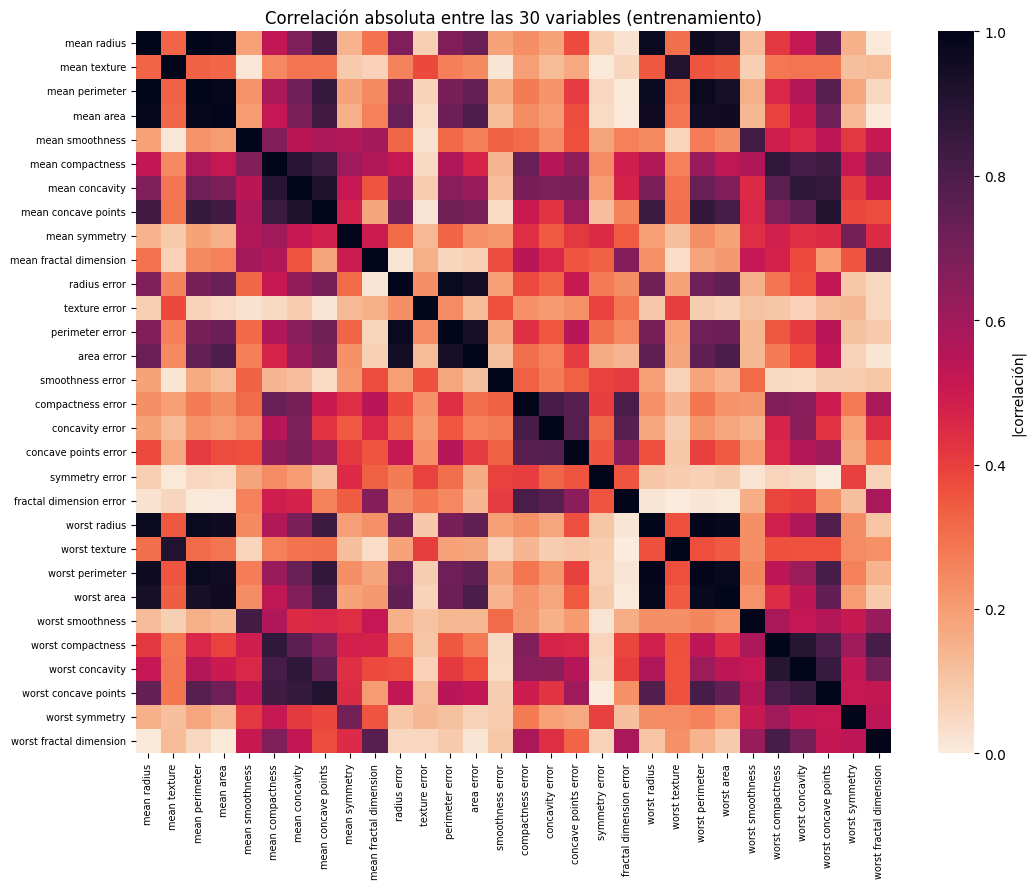

In [6]:
corr = X_train.corr().abs()

# Pares de variables con correlación absoluta mayor a 0.95
mascara = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pares = (
    corr.where(mascara)
        .stack()
        .sort_values(ascending=False)
        .rename("|r|")
)
pares_altos = pares[pares > 0.95]
print(f"Pares con |r| > 0.95: {len(pares_altos)}\n")
print(pares_altos.to_string())

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="rocket_r", vmin=0, vmax=1,
            xticklabels=True, yticklabels=True, cbar_kws={"label": "|correlación|"})
plt.title("Correlación absoluta entre las 30 variables (entrenamiento)")
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

**¿Qué hace este código?**

- `X_train.corr()`: calcula la correlación entre cada par de variables (de −1 a 1). `.abs()` quita el signo porque interesa la fuerza de la relación, no su dirección.
- `mascara = np.triu(..., k=1)`: la tabla de correlación es simétrica (A con B = B con A). `np.triu` marca solo el triángulo de arriba, sin la diagonal (`k=1`), para no contar cada par dos veces ni comparar una variable consigo misma.
- `corr.where(mascara)`: deja solo los valores del triángulo superior. `.stack()` convierte la tabla en una lista de pares. `.sort_values(ascending=False)` los ordena de mayor a menor.
- `pares[pares > 0.95]`: se queda con los pares casi idénticos y los imprime.
- `sns.heatmap(...)`: dibuja la matriz como un mapa de calor; los colores oscuros son correlaciones altas. `vmin=0, vmax=1` fija la escala de color.
- `plt.xticks(fontsize=7)`: letra pequeña para que quepan los 30 nombres.

**Lectura:** hay bloques enteros de variables redundantes. El radio, el perímetro y el área están correlacionados a más de 0.99 (tiene sentido geométrico: el perímetro y el área se calculan a partir del radio), y lo mismo ocurre entre sus versiones «mean» y «worst». En la práctica, varias columnas aportan casi la misma información, lo que justifica intentar un modelo con menos variables.

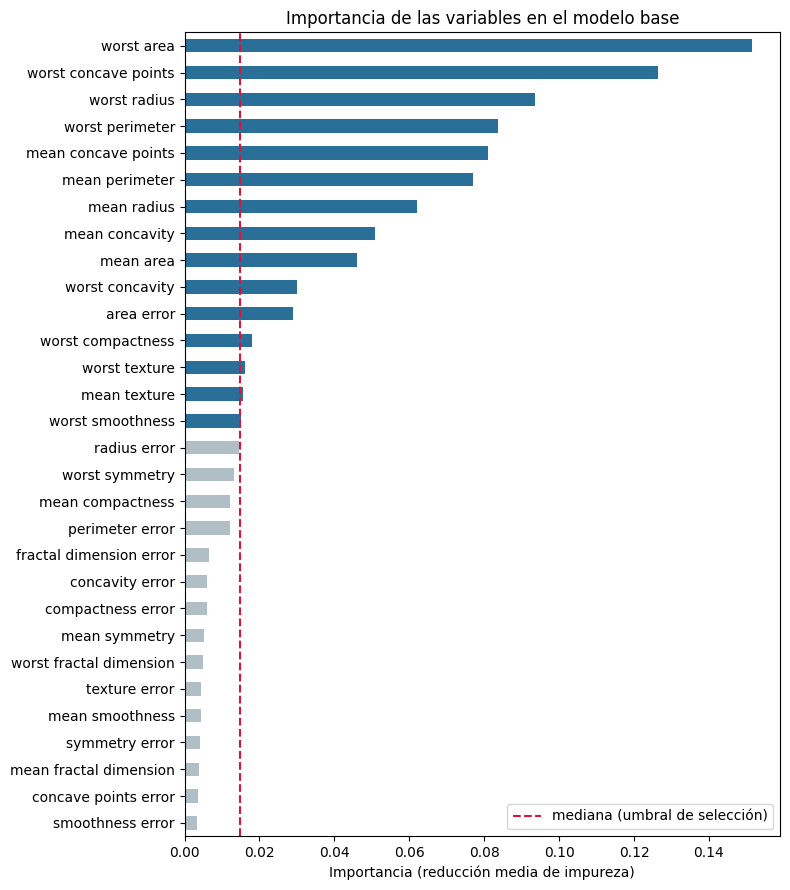

Las 10 variables menos importantes suman 4.5% de la importancia total.


In [7]:
importancias = pd.Series(
    modelo_base.named_steps["rf"].feature_importances_,
    index=X.columns,
).sort_values()

plt.figure(figsize=(8, 9))
colores = ["#2a6f97" if v >= importancias.median() else "#b0bec5" for v in importancias]
importancias.plot.barh(color=colores)
plt.axvline(importancias.median(), color="crimson", ls="--", label="mediana (umbral de selección)")
plt.xlabel("Importancia (reducción media de impureza)")
plt.title("Importancia de las variables en el modelo base")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Las 10 variables menos importantes suman {importancias.head(10).sum():.1%} de la importancia total.")

**¿Qué hace este código?**

- `modelo_base.named_steps["rf"].feature_importances_`: el Random Forest ya entrenado guarda cuánto contribuyó cada variable a separar las clases (suman 1 entre todas).
- `pd.Series(..., index=X.columns)`: pone cada importancia junto al nombre de su variable. `.sort_values()` las ordena de menor a mayor.
- `colores = [...]`: una *list comprehension* (lista construida en una línea). Recorre cada importancia `v` y elige azul si está en la mitad superior (≥ mediana) y gris si no.
- `importancias.plot.barh(...)`: gráfica de barras horizontales.
- `plt.axvline(...)`: línea vertical roja en la mediana, que será el umbral de la selección del paso siguiente.
- El `print` suma la importancia de las 10 variables menos útiles; `:.1%` la muestra como porcentaje con un decimal.

**Lectura:** la importancia está muy concentrada. Las variables de «peor valor» (`worst`) y las de concavidad dominan, mientras que casi todas las de error estándar (`... error`), la simetría y la dimensión fractal aportan muy poco.

## 7. Selección de características con `SelectFromModel`

**Criterio del método.** `SelectFromModel` entrena un Random Forest auxiliar, lee la importancia de cada variable (cuánto reduce en promedio la impureza de Gini en los nodos donde se usa) y **conserva solo las variables cuya importancia supera un umbral**. Se usa `threshold="median"`, que conserva exactamente la mitad más importante: **15 de 30 variables**.

**¿Por qué esta técnica y no PCA?** Porque es compatible con el modelo (usa la propia lógica de los árboles), funciona con clasificación y **conserva las variables originales**: el resultado sigue siendo interpretable («el modelo usa el área y la concavidad»). PCA combinaría las variables en componentes abstractos que ya no tienen significado clínico directo.

**Sin fuga de información.** El selector va **dentro del pipeline**. Así, cada vez que el pipeline se entrena —con el conjunto de entrenamiento o con cada partición de la validación cruzada— la selección se recalcula únicamente con esos datos. El conjunto de prueba nunca participa en decidir qué variables se quedan.

In [8]:
modelo_reducido = Pipeline([
    ("escala", StandardScaler()),
    ("seleccion", SelectFromModel(
        RandomForestClassifier(random_state=RANDOM_STATE),
        threshold="median",
    )),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE)),
])

res_reducido = evaluar(modelo_reducido, "Reducido")

conservadas = X.columns[modelo_reducido.named_steps["seleccion"].get_support()]
eliminadas = X.columns[~modelo_reducido.named_steps["seleccion"].get_support()]

print(f"Variables conservadas ({len(conservadas)}):")
for v in conservadas:
    print("   +", v)
print(f"\nVariables eliminadas ({len(eliminadas)}):")
print("   ", ", ".join(eliminadas))

Variables conservadas (15):
   + mean radius
   + mean texture
   + mean perimeter
   + mean area
   + mean concavity
   + mean concave points
   + area error
   + worst radius
   + worst texture
   + worst perimeter
   + worst area
   + worst smoothness
   + worst compactness
   + worst concavity
   + worst concave points

Variables eliminadas (15):
    mean smoothness, mean compactness, mean symmetry, mean fractal dimension, radius error, texture error, perimeter error, smoothness error, compactness error, concavity error, concave points error, symmetry error, fractal dimension error, worst symmetry, worst fractal dimension


**¿Qué hace este código?**

- `modelo_reducido = Pipeline([...])`: igual que el modelo base, pero con un paso intermedio:
  1. `"escala"`: estandariza.
  2. `"seleccion"`: `SelectFromModel` con su propio Random Forest (con la misma semilla) y `threshold="median"`: deja pasar solo las variables con importancia mayor o igual a la mediana.
  3. `"rf"`: el Random Forest final, con los mismos parámetros por defecto que el base, que ahora solo ve 15 columnas.
- `evaluar(modelo_reducido, "Reducido")`: se mide con la **misma función**, la misma partición y las mismas métricas que el base.
- `get_support()`: devuelve una lista de `True`/`False` indicando qué columnas pasaron el filtro. `X.columns[...]` convierte esa lista en los nombres.
- `~`: significa «lo contrario»; invierte `True` y `False` para obtener las eliminadas.
- `for v in conservadas: print(...)`: imprime una variable por línea. `", ".join(eliminadas)` une los nombres en un solo texto separado por comas.

**Efecto sobre la representación de los datos:** cada tumor pasa de describirse con 30 números a describirse con 15, **en las mismas unidades originales**. Se conservan sobre todo las medidas de tamaño (radio, perímetro, área), la concavidad y los peores valores; se eliminan casi todos los errores estándar, la simetría y la dimensión fractal. Nótese que la selección **no elimina toda la redundancia**: radio, perímetro y área siguen juntos porque los tres son individualmente importantes. `SelectFromModel` juzga cada variable por separado, no por pares.

### ¿Por qué 15 variables? Sensibilidad al número de características

El umbral de la mediana es una elección razonable, pero conviene comprobar qué pasa con más o menos variables. Se evalúa el recall con **validación cruzada sobre el entrenamiento** (sin tocar la prueba) conservando las k variables más importantes.

,Recall CV,Desv. recall,F1 CV,ROC-AUC CV
k,,,,
3,0.9059,0.0600,0.9133,0.9818
5,0.9118,0.0372,0.9200,0.9778
8,0.9059,0.0288,0.9197,0.9822
10,0.9235,0.0478,0.9316,0.9837
15,0.9353,0.0288,0.9438,0.9854
20,0.9412,0.0416,0.9548,0.9895
25,0.9235,0.0440,0.9426,0.9881
30,0.9412,0.0416,0.9519,0.9889


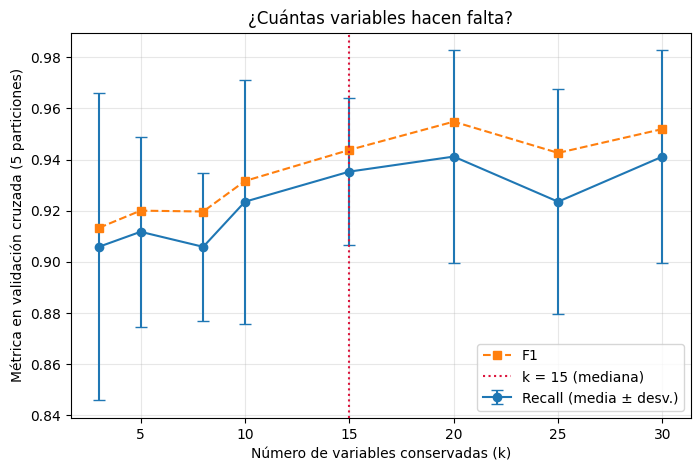

In [9]:
filas = []
for k in [3, 5, 8, 10, 15, 20, 25, 30]:
    pipe_k = Pipeline([
        ("escala", StandardScaler()),
        ("seleccion", SelectFromModel(
            RandomForestClassifier(random_state=RANDOM_STATE),
            max_features=k, threshold=-np.inf,
        )),
        ("rf", RandomForestClassifier(random_state=RANDOM_STATE)),
    ])
    r = cross_validate(pipe_k, X_train, y_train, cv=cv,
                       scoring=["recall", "f1", "roc_auc"], n_jobs=-1)
    filas.append({"k": k,
                  "Recall CV": r["test_recall"].mean(),
                  "Desv. recall": r["test_recall"].std(),
                  "F1 CV": r["test_f1"].mean(),
                  "ROC-AUC CV": r["test_roc_auc"].mean()})

curva_k = pd.DataFrame(filas).set_index("k")
display(curva_k)

plt.figure()
plt.errorbar(curva_k.index, curva_k["Recall CV"], yerr=curva_k["Desv. recall"],
             marker="o", capsize=4, label="Recall (media ± desv.)")
plt.plot(curva_k.index, curva_k["F1 CV"], marker="s", ls="--", label="F1")
plt.axvline(15, color="crimson", ls=":", label="k = 15 (mediana)")
plt.xlabel("Número de variables conservadas (k)")
plt.ylabel("Métrica en validación cruzada (5 particiones)")
plt.title("¿Cuántas variables hacen falta?")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**¿Qué hace este código?**

- `filas = []`: lista donde se guardará una fila de resultados por cada valor de k.
- `for k in [3, 5, ..., 30]:` repite el experimento para distintas cantidades de variables.
- `SelectFromModel(..., max_features=k, threshold=-np.inf)`: `threshold=-np.inf` (menos infinito) desactiva el umbral para que el único criterio sea «quédate con las `k` más importantes».
- `cross_validate(pipe_k, X_train, y_train, cv=cv, ...)`: entrena y evalúa el pipeline 5 veces, cada vez con un corte distinto del **entrenamiento**. Devuelve un diccionario con las 5 calificaciones de cada métrica. `n_jobs=-1` usa todos los núcleos del procesador para ir más rápido.
- `r["test_recall"].mean()` y `.std()`: promedio y desviación estándar de las 5 calificaciones.
- `filas.append({...})`: agrega los resultados de ese k a la lista.
- `pd.DataFrame(filas).set_index("k")`: convierte la lista en tabla; `display` la muestra.
- `plt.errorbar(...)`: dibuja el recall promedio con «bigotes» que indican su variación entre particiones. `capsize=4` dibuja las rayitas en los extremos.
- `plt.axvline(15, ...)`: marca la opción elegida.

**Lectura:** con muy pocas variables (3–5) el recall cae porque se pierde información. A partir de ~10 variables la curva se aplana: agregar más columnas ya no mejora de forma consistente, y las diferencias entre k = 15, 20 y 30 son menores que la desviación entre particiones. Esto confirma que **15 variables es una zona segura**: la mitad de las columnas sin pérdida relevante.

## 8. Comparación: modelo base vs modelo reducido

Misma partición, misma semilla, mismas métricas.

In [10]:
tabla_1 = pd.DataFrame([res_base, res_reducido]).set_index("Modelo")
tabla_1.index = ["Modelo base", "Modelo con selección (SelectFromModel)"]
tabla_1.index.name = "Configuración"
tabla_1[["Características", "Recall (principal)", "F1", "ROC-AUC", "Tiempo entrenamiento (s)"]]

,Características,Recall (principal),F1,ROC-AUC,Tiempo entrenamiento (s)
Configuración,,,,,
Modelo base,30,0.9286,0.963,0.9929,0.1451
Modelo con selección (SelectFromModel),15,0.9286,0.963,0.9952,0.2738


**¿Qué hace este código?**

- `pd.DataFrame([res_base, res_reducido])`: junta los dos diccionarios de resultados en una tabla de dos filas.
- `tabla_1.index = [...]` y `tabla_1.index.name = ...`: pone los nombres de fila y el encabezado que pide la actividad.
- `tabla_1[[...]]`: muestra solo las columnas de la tabla solicitada, en ese orden.

| Configuración | Número de características | Métrica principal (recall) | Métrica complementaria (F1 / ROC-AUC) | Tiempo de entrenamiento |
|---|---|---|---|---|
| Modelo base | 30 | 0.9286 | 0.9630 / 0.9929 | 0.15 s |
| Modelo con selección (`SelectFromModel`, umbral = mediana) | 15 | 0.9286 | 0.9630 / 0.9952 | 0.27 s |

*Tiempo = mínimo de 5 entrenamientos del pipeline completo sobre las 455 filas de entrenamiento. Los tiempos varían ligeramente entre ejecuciones y computadoras; lo relevante es la proporción entre ellos.*

**Interpretación.** La reducción **conservó resultados prácticamente iguales con la mitad de la complejidad**:

- El **recall es idéntico** (0.9286): ambos modelos detectan 39 de los 42 malignos de prueba y fallan en los mismos 3 casos.
- El **F1 es idéntico** (0.9630), porque ninguno de los dos tiene falsos positivos.
- El **ROC-AUC sube ligeramente** (0.9929 → 0.9952): con menos variables ruidosas, el modelo ordena un poco mejor las probabilidades.
- **No hubo pérdida importante de información**: las 15 variables descartadas eran, en su mayoría, redundantes o poco informativas.

**Un matiz sobre el tiempo:** el pipeline reducido **tarda más en entrenar**, no menos. La razón es que `SelectFromModel` entrena un Random Forest auxiliar para decidir qué variables conservar, así que en total se entrenan dos bosques. La ganancia de eficiencia real está en la **predicción** y en la **recolección de datos**: en producción el modelo solo necesita 15 mediciones por paciente en lugar de 30. Si la selección se hiciera una sola vez y se fijaran las 15 columnas, el entrenamiento sí sería más rápido que el base.

## 9. Ajuste de hiperparámetros con `GridSearchCV`

Se optimiza el **modelo reducido** (el pipeline completo, con el selector dentro). Hiperparámetros explorados del Random Forest final:

- `n_estimators`: número de árboles del bosque.
- `max_depth`: profundidad máxima de cada árbol; limitarla reduce el sobreajuste.
- `min_samples_split`: mínimo de observaciones para dividir un nodo.
- `max_features`: cuántas variables considera cada árbol en cada división; menos variables = árboles más distintos entre sí.
- `class_weight`: `"balanced"` da más peso a la clase minoritaria (malignos), lo cual está directamente alineado con el recall.

**Estrategia de validación:** `StratifiedKFold` con **5 particiones** estratificadas y mezcladas (semilla 42), aplicada **solo sobre el conjunto de entrenamiento**.

**Métrica de selección:** **recall** (la métrica principal); los empates se resuelven con **ROC-AUC**. También se registra F1 para cada combinación.

**Espacio de búsqueda:** 3 × 3 × 3 × 3 × 2 = **162 combinaciones × 5 particiones = 810 entrenamientos**. Es acotado y viable (entre uno y cinco minutos según la computadora).

In [11]:
espacio = {
    "rf__n_estimators": [100, 300, 500],
    "rf__max_depth": [None, 5, 10],
    "rf__min_samples_split": [2, 5, 10],
    "rf__max_features": ["sqrt", "log2", 0.5],
    "rf__class_weight": [None, "balanced"],
}

def mejor_recall_con_desempate(resultados):
    tabla = pd.DataFrame(resultados)
    mejor_recall = tabla["mean_test_recall"].max()
    empatadas = tabla[np.isclose(tabla["mean_test_recall"], mejor_recall)]
    return empatadas["mean_test_roc_auc"].idxmax()


busqueda = GridSearchCV(
    estimator=modelo_reducido,
    param_grid=espacio,
    cv=cv,
    scoring={"recall": "recall", "f1": "f1", "roc_auc": "roc_auc"},
    refit=mejor_recall_con_desempate,
    n_jobs=-1,
    return_train_score=True,
)

inicio = time.perf_counter()
busqueda.fit(X_train, y_train)
tiempo_busqueda = time.perf_counter() - inicio

n_comb = len(busqueda.cv_results_["params"])
print(f"Combinaciones evaluadas: {n_comb} | entrenamientos: {n_comb * cv.get_n_splits()}")
print(f"Tiempo total de la búsqueda: {tiempo_busqueda:.1f} s")
mejor = busqueda.best_index_
empates = np.isclose(busqueda.cv_results_["mean_test_recall"],
                     busqueda.cv_results_["mean_test_recall"][mejor]).sum()
print(f"Mejor recall promedio en validación cruzada: {busqueda.cv_results_['mean_test_recall'][mejor]:.4f}")
print(f"Combinaciones empatadas con ese recall: {empates} -> desempate por ROC-AUC "
      f"({busqueda.cv_results_['mean_test_roc_auc'][mejor]:.4f})")
print("Mejores hiperparámetros:", busqueda.best_params_)

Combinaciones evaluadas: 162 | entrenamientos: 810
Tiempo total de la búsqueda: 130.9 s
Mejor recall promedio en validación cruzada: 0.9353
Combinaciones empatadas con ese recall: 37 -> desempate por ROC-AUC (0.9867)
Mejores hiperparámetros: {'rf__class_weight': 'balanced', 'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 10, 'rf__n_estimators': 500}


**¿Qué hace este código?**

- `def mejor_recall_con_desempate(resultados):` define la **regla para elegir la ganadora**. Con ~34 malignos por partición, el recall solo puede tomar unos cuantos valores y muchas combinaciones **empatan**. Sin una regla de desempate, scikit-learn tomaría simplemente la primera de la lista (que coincide con los valores por defecto), lo cual es arbitrario. La función:
  - `pd.DataFrame(resultados)`: convierte los resultados de todas las combinaciones en tabla.
  - `tabla["mean_test_recall"].max()`: encuentra el mejor recall promedio.
  - `np.isclose(...)`: se queda con todas las combinaciones que alcanzan ese recall (`isclose` compara decimales tolerando diferencias diminutas de redondeo).
  - `empatadas["mean_test_roc_auc"].idxmax()`: entre las empatadas, devuelve la posición de la que tiene mayor ROC-AUC. Así **el recall sigue siendo el criterio principal** y la métrica complementaria solo decide los empates.
- `espacio = {...}`: diccionario con los valores a probar. El prefijo `rf__` (dos guiones bajos) le indica al pipeline que el parámetro pertenece al paso llamado `"rf"`. En `max_features`, `0.5` significa «la mitad de las variables».
- `GridSearchCV(...)`: prepara la búsqueda en rejilla:
  - `estimator=modelo_reducido`: el pipeline completo; así la selección de variables también se rehace dentro de cada partición y no hay fuga de información.
  - `param_grid=espacio`: prueba **todas** las combinaciones.
  - `cv=cv`: la validación cruzada estratificada de 5 particiones definida en el paso 4.
  - `scoring={...}`: calcula tres métricas por combinación.
  - `refit=mejor_recall_con_desempate`: le indica cómo elegir la combinación ganadora, que al final se reentrena con todo el conjunto de entrenamiento.
  - `n_jobs=-1`: usa todos los núcleos en paralelo.
  - `return_train_score=True`: guarda también la calificación en entrenamiento, para detectar sobreajuste.
- `busqueda.fit(X_train, y_train)`: ejecuta los 810 entrenamientos. **Solo recibe datos de entrenamiento.**
- `time.perf_counter()` antes y después: mide el costo total de la búsqueda.
- `busqueda.best_index_`: posición de la combinación ganadora; con ella se leen su recall y su ROC-AUC en `busqueda.cv_results_` (la tabla interna con los resultados de cada combinación).
- `np.isclose(...).sum()`: cuenta cuántas combinaciones empataron en el mejor recall.
- `busqueda.best_params_`: la configuración ganadora.

In [12]:
resultados_cv = pd.DataFrame(busqueda.cv_results_)

tabla_hp = pd.DataFrame({
    "Hiperparámetro": [p.replace("rf__", "") for p in espacio],
    "Valores explorados": [", ".join(map(str, v)) for v in espacio.values()],
    "Mejor valor": [str(busqueda.best_params_[p]) for p in espacio],
    "Valor en el modelo base": ["100", "None", "2", "sqrt", "None"],
}).set_index("Hiperparámetro")
display(tabla_hp)

top = (resultados_cv
       .sort_values(["rank_test_recall", "mean_test_roc_auc"], ascending=[True, False])
       .head(8))
top_vista = pd.DataFrame({
    "Configuración": top["params"].apply(lambda d: {k.replace("rf__", ""): v for k, v in d.items()}),
    "Recall CV": top["mean_test_recall"],
    "Desv. recall": top["std_test_recall"],
    "F1 CV": top["mean_test_f1"],
    "ROC-AUC CV": top["mean_test_roc_auc"],
    "Recall entrenamiento": top["mean_train_recall"],
})
pd.set_option("display.max_colwidth", None)
top_vista.reset_index(drop=True)

,Valores explorados,Mejor valor,Valor en el modelo base
Hiperparámetro,,,
n_estimators,"100, 300, 500",500,100
max_depth,"None, 5, 10",None,None
min_samples_split,"2, 5, 10",10,2
max_features,"sqrt, log2, 0.5",sqrt,sqrt
class_weight,"None, balanced",balanced,None


,Configuración,Recall CV,Desv. recall,F1 CV,ROC-AUC CV,Recall entrenamiento
0,"{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 500}",0.9353,0.0343,0.9381,0.9867,0.9838
1,"{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 500}",0.9353,0.0343,0.9381,0.9867,0.9838
2,"{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 500}",0.9353,0.0343,0.9381,0.9867,0.9838
3,"{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 500}",0.9353,0.0343,0.9381,0.9867,0.9838
4,"{'class_weight': 'balanced', 'max_depth': None, 'max_features': 0.5, 'min_samples_split': 10, 'n_estimators': 500}",0.9353,0.0343,0.9327,0.9866,0.9853
5,"{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 0.5, 'min_samples_split': 10, 'n_estimators': 500}",0.9353,0.0343,0.9327,0.9866,0.9824
6,"{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 0.5, 'min_samples_split': 10, 'n_estimators': 500}",0.9353,0.0343,0.9327,0.9866,0.9853
7,"{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 500}",0.9353,0.0343,0.9381,0.9865,0.9985


**¿Qué hace este código?**

- `pd.DataFrame(busqueda.cv_results_)`: convierte los resultados de las 162 combinaciones en una tabla.
- `tabla_hp`: construye la tabla que pide la actividad.
  - `p.replace("rf__", "")`: quita el prefijo para que el nombre se lea limpio.
  - `", ".join(map(str, v))`: `map(str, v)` convierte cada valor a texto y `join` los une con comas.
  - `busqueda.best_params_[p]`: el valor ganador de cada hiperparámetro.
  - Se agrega una columna con el valor que tenía el modelo base, para ver qué cambió.
- `top = resultados_cv.sort_values(...)`: ordena las combinaciones por su lugar en recall (`rank_test_recall`, 1 = mejor) y, en caso de empate, por ROC-AUC. `.head(8)` toma las 8 mejores.
- `top_vista`: tabla resumida. `.apply(lambda d: ...)` recorre cada configuración y le quita el prefijo `rf__` a sus nombres. `lambda` es una función pequeña escrita en una línea.
- `mean_train_recall`: recall en las particiones de entrenamiento; compararlo con el de validación indica cuánto memoriza cada configuración.
- `display.max_colwidth = None`: evita que pandas recorte el texto largo de las configuraciones.

| Hiperparámetro | Valores explorados | Mejor valor |
|---|---|---|
| `n_estimators` | 100, 300, 500 | **500** |
| `max_depth` | None, 5, 10 | None |
| `min_samples_split` | 2, 5, 10 | **10** |
| `max_features` | sqrt, log2, 0.5 | sqrt |
| `class_weight` | None, balanced | **balanced** |

- **Estrategia de validación:** `StratifiedKFold`, validación cruzada estratificada con mezcla y semilla 42, solo sobre el entrenamiento.
- **Número de particiones:** 5 (cada combinación se entrena 5 veces; 810 entrenamientos en total, ≈ 131 s).
- **Métrica de selección:** recall promedio de las 5 particiones; desempate por ROC-AUC promedio.

**Lectura.** El resultado más revelador de la búsqueda es el **empate**: 37 de las 162 combinaciones alcanzan el mismo recall promedio (0.9353), que además es el mismo recall que ya tenía el modelo reducido con sus parámetros por defecto. Con ~34 malignos por partición, el recall se mueve en saltos de ~3 puntos (un caso), así que los hiperparámetros **no logran que el modelo detecte más cánceres**.

Entre las empatadas, el desempate por ROC-AUC eligió una configuración con tres cambios respecto al modelo base, todos con sentido:

- `class_weight="balanced"`: da más peso a los malignos, alineado con el objetivo de no dejarlos escapar.
- `min_samples_split=10`: impide que los árboles se dividan hasta aislar observaciones individuales; es una forma de **regularización** (menos memorización).
- `n_estimators=500`: más árboles promedian mejor y estabilizan las probabilidades, a cambio de más tiempo de entrenamiento (5 veces más árboles).

En la tabla de las mejores configuraciones se ve que las primeras 8 comparten `class_weight="balanced"`, `min_samples_split` alto y 500 árboles: la búsqueda apunta de forma consistente hacia **árboles menos sobreajustados y un bosque más grande**. La profundidad y `max_features` casi no influyen.

### ¿Por qué validación cruzada y no una sola división?

Con una sola división, la calificación depende de **qué casos cayeron por azar** en el grupo de validación. En este dataset el conjunto de validación tendría ~34 malignos, así que **un solo caso cambia el recall en casi 3 puntos**: dos configuraciones podrían parecer distintas solo por suerte. La validación cruzada entrena y evalúa 5 veces con cortes distintos y promedia; además, la desviación estándar entre particiones indica **qué tan confiable** es cada diferencia. Así se comparan alternativas con mucha mayor estabilidad.

### ¿Por qué el conjunto de prueba se reserva para el final?

Si se eligieran hiperparámetros mirando la prueba, se estaría escogiendo la configuración que mejor se adapta a **esos 114 casos concretos**, y la métrica final sería optimista: ya no mediría el desempeño con datos nuevos, sino la capacidad de adivinar la prueba. Al reservarla, el conjunto de prueba funciona como un **examen que el modelo nunca vio**, y su resultado es una estimación honesta de la generalización.

## 10. Modelo optimizado y comparación de los tres modelos

In [13]:
modelo_optimizado = busqueda.best_estimator_
res_optimizado = evaluar(modelo_optimizado, "Optimizado")

tabla_final = pd.DataFrame([res_base, res_reducido, res_optimizado]).set_index("Modelo")
tabla_final[["Recall (principal)", "F1", "ROC-AUC", "Características", "Tiempo entrenamiento (s)", "Precisión", "Accuracy"]]

,Recall (principal),F1,ROC-AUC,Características,Tiempo entrenamiento (s),Precisión,Accuracy
Modelo,,,,,,,
Base,0.9286,0.963,0.9929,30,0.1451,1.0,0.9737
Reducido,0.9286,0.963,0.9952,15,0.2738,1.0,0.9737
Optimizado,0.9286,0.963,0.9970,15,1.6080,1.0,0.9737


**¿Qué hace este código?**

- `busqueda.best_estimator_`: el pipeline con los mejores hiperparámetros, ya reentrenado con todo el entrenamiento.
- `evaluar(modelo_optimizado, "Optimizado")`: lo mide exactamente igual que a los otros dos (misma partición, mismas métricas, mismo cronómetro). **Es la primera y única vez que el modelo optimizado toca el conjunto de prueba.**
- `pd.DataFrame([...])`: junta los tres resultados en una sola tabla con las columnas que pide la actividad (más precisión y accuracy como referencia).

Como el conjunto de prueba es pequeño (42 malignos), una sola predicción mueve el recall 2.4 puntos. Para juzgar la **estabilidad**, se evalúan también los tres modelos con la misma validación cruzada sobre el entrenamiento y se compara el desempeño en entrenamiento contra prueba (**riesgo de sobreajuste**).

In [14]:
modelos = {"Base": modelo_base, "Reducido": modelo_reducido, "Optimizado": modelo_optimizado}

estabilidad = {}
filas = []
for nombre, m in modelos.items():
    r = cross_validate(m, X_train, y_train, cv=cv,
                       scoring=["recall", "f1", "roc_auc"], n_jobs=-1)
    estabilidad[nombre] = r["test_recall"]
    recall_train = recall_score(y_train, m.predict(X_train))
    recall_test = recall_score(y_test, m.predict(X_test))
    filas.append({
        "Modelo": nombre,
        "Recall CV (media)": r["test_recall"].mean(),
        "Recall CV (desv.)": r["test_recall"].std(),
        "F1 CV": r["test_f1"].mean(),
        "ROC-AUC CV": r["test_roc_auc"].mean(),
        "Recall entrenamiento": recall_train,
        "Recall prueba": recall_test,
        "Brecha entren. − prueba": recall_train - recall_test,
    })

tabla_estabilidad = pd.DataFrame(filas).set_index("Modelo")
tabla_estabilidad

,Recall CV (media),Recall CV (desv.),F1 CV,ROC-AUC CV,Recall entrenamiento,Recall prueba,Brecha entren. − prueba
Modelo,,,,,,,
Base,0.9412,0.0416,0.9519,0.9889,1.0000,0.9286,0.0714
Reducido,0.9353,0.0288,0.9438,0.9854,1.0000,0.9286,0.0714
Optimizado,0.9353,0.0343,0.9381,0.9867,0.9824,0.9286,0.0538


**¿Qué hace este código?**

- `modelos = {...}`: diccionario que asocia un nombre con cada modelo, para recorrerlos en un ciclo.
- `for nombre, m in modelos.items():` recorre los tres modelos; en cada vuelta `nombre` es el texto y `m` el modelo.
- `cross_validate(...)`: evalúa cada modelo con **las mismas 5 particiones** del entrenamiento.
- `estabilidad[nombre] = r["test_recall"]`: guarda las 5 calificaciones de recall para graficarlas después.
- `recall_score(y_train, m.predict(X_train))`: recall sobre los mismos datos con los que se entrenó. Si es mucho mayor que el de prueba, el modelo está memorizando.
- `"Brecha entren. − prueba"`: la resta de ambos; cuanto más cerca de 0, mejor generaliza.

| Modelo | Métrica principal (recall) | Métrica complementaria (F1 / ROC-AUC) | Características | Tiempo |
|---|---|---|---|---|
| Base | 0.9286 | 0.9630 / 0.9929 | 30 | 0.15 s |
| Reducido | 0.9286 | 0.9630 / 0.9952 | 15 | 0.27 s |
| Optimizado | 0.9286 | 0.9630 / **0.9970** | 15 | 1.61 s |

**Lectura de las dos tablas:**

- **En prueba, los tres modelos toman exactamente las mismas decisiones:** 39 de 42 malignos detectados, 3 falsos negativos y ningún falso positivo. Por eso recall, F1, precisión y accuracy son idénticos.
- **La única métrica de prueba que mejora es el ROC-AUC** (0.9929 → 0.9952 → 0.9970). El modelo optimizado asigna probabilidades mejor ordenadas: los malignos que no detecta quedan más cerca del umbral de 0.5, así que serían más fáciles de rescatar ajustando el umbral.
- **En validación cruzada no hay ganador claro.** El recall medio va de 0.9353 a 0.9412, una diferencia de 0.006, que es menos de un caso por partición y bastante menor que la desviación entre particiones (0.03–0.04). El base incluso tiene el F1 de validación más alto.
- **El sobreajuste sí se reduce.** El base y el reducido tienen recall de 1.000 en entrenamiento, es decir, memorizan todos los malignos que ven. El optimizado baja a 0.982 y la brecha entrenamiento–prueba se reduce de 0.071 a 0.054, gracias a `min_samples_split=10`.

## 11. Visualizaciones comparativas

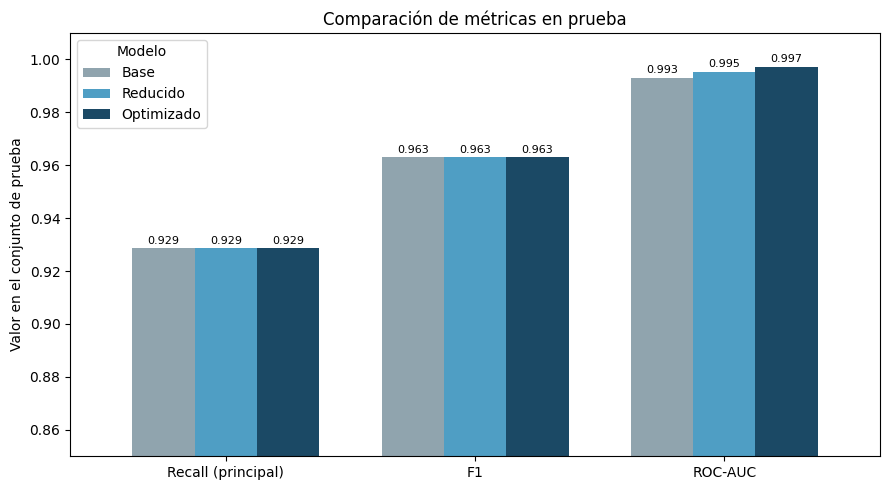

In [15]:
metricas = ["Recall (principal)", "F1", "ROC-AUC"]
datos_graf = tabla_final[metricas].T

ax = datos_graf.plot.bar(figsize=(9, 5), color=["#90a4ae", "#4f9ec4", "#1b4965"], width=0.75)
for barra in ax.containers:
    ax.bar_label(barra, fmt="%.3f", fontsize=8, padding=2)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("Valor en el conjunto de prueba")
ax.set_title("Comparación de métricas en prueba")
ax.set_xticklabels(datos_graf.index, rotation=0)
ax.legend(title="Modelo", loc="upper left")
plt.tight_layout()
plt.show()

**¿Qué hace este código?**

- `tabla_final[metricas].T`: toma las tres métricas y **transpone** la tabla (`.T` intercambia filas y columnas) para que cada grupo de barras sea una métrica y cada color un modelo.
- `.plot.bar(...)`: gráfica de barras agrupadas con un color por modelo.
- `for barra in ax.containers: ax.bar_label(...)`: escribe el valor encima de cada barra con 3 decimales.
- `ax.set_ylim(0.85, 1.01)`: el eje vertical empieza en 0.85 para que las diferencias pequeñas se aprecien. **Ojo:** esto exagera visualmente las diferencias; por eso se muestran los valores exactos en cada barra.

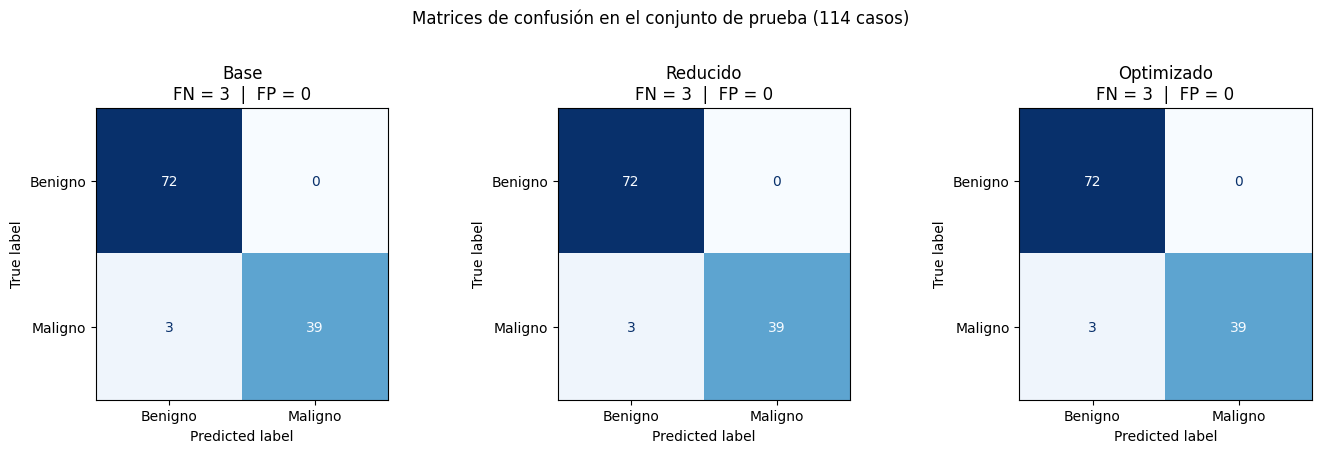

In [16]:
fig, ejes = plt.subplots(1, 3, figsize=(14, 4.3))
for eje, (nombre, m) in zip(ejes, modelos.items()):
    ConfusionMatrixDisplay.from_estimator(
        m, X_test, y_test,
        display_labels=["Benigno", "Maligno"],
        cmap="Blues", colorbar=False, ax=eje,
    )
    vn, fp, fn, vp = confusion_matrix(y_test, m.predict(X_test)).ravel()
    eje.set_title(f"{nombre}\nFN = {fn}  |  FP = {fp}")
plt.suptitle("Matrices de confusión en el conjunto de prueba (114 casos)", y=1.03)
plt.tight_layout()
plt.show()

**¿Qué hace este código?**

- `plt.subplots(1, 3, ...)`: crea una figura con 3 paneles lado a lado; `ejes` es la lista de los tres paneles.
- `zip(ejes, modelos.items())`: empareja cada panel con un modelo, para dibujar uno en cada panel.
- `ConfusionMatrixDisplay.from_estimator(m, X_test, y_test, ...)`: predice la prueba con el modelo y dibuja la matriz de confusión: filas = clase real, columnas = clase predicha.
- `confusion_matrix(...).ravel()`: devuelve la matriz 2 × 2 «aplanada» en cuatro números en este orden: verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos.
- `eje.set_title(...)`: pone en el título el número de falsos negativos (FN, cánceres no detectados) y falsos positivos (FP).

**Lectura:** los tres modelos cometen **exactamente los mismos errores en prueba**: 3 falsos negativos y 0 falsos positivos. La optimización no cambió ninguna predicción final con el umbral de 0.5.

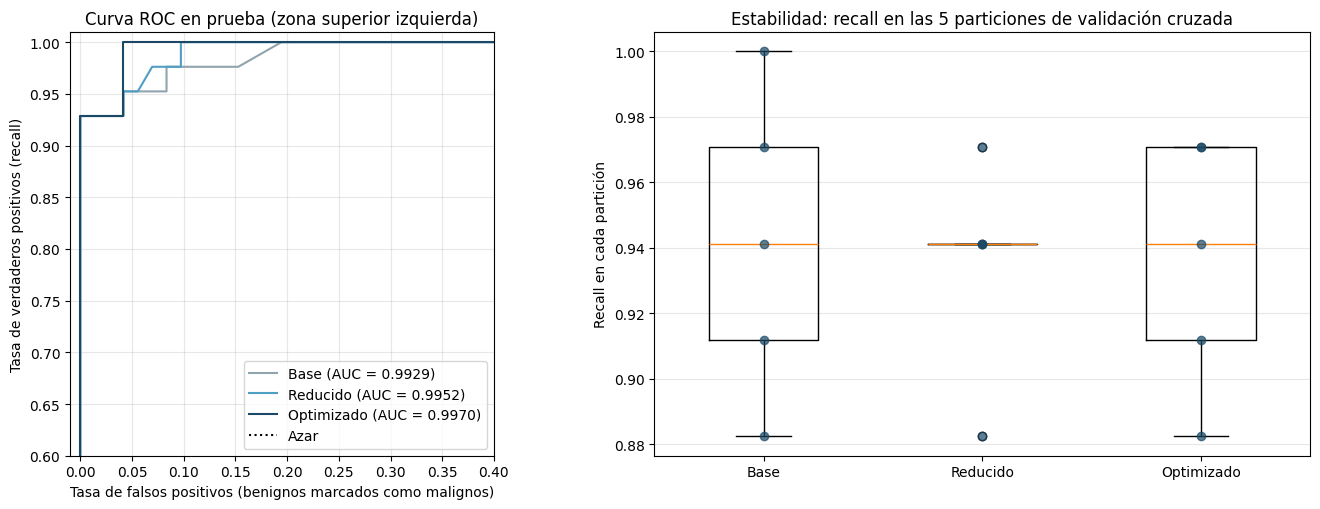

In [17]:
fig, (eje_roc, eje_box) = plt.subplots(1, 2, figsize=(14, 5.2))

for (nombre, m), color in zip(modelos.items(), ["#90a4ae", "#4f9ec4", "#1b4965"]):
    RocCurveDisplay.from_estimator(m, X_test, y_test, name=nombre, color=color, ax=eje_roc)
    auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    eje_roc.lines[-1].set_label(f"{nombre} (AUC = {auc:.4f})")
eje_roc.plot([0, 1], [0, 1], "k:", label="Azar")
eje_roc.set_xlabel("Tasa de falsos positivos (benignos marcados como malignos)")
eje_roc.set_ylabel("Tasa de verdaderos positivos (recall)")
eje_roc.set_xlim(-0.01, 0.4)
eje_roc.set_ylim(0.6, 1.01)
eje_roc.set_title("Curva ROC en prueba (zona superior izquierda)")
eje_roc.legend(loc="lower right")
eje_roc.grid(alpha=0.3)

eje_box.boxplot(list(estabilidad.values()), tick_labels=list(estabilidad.keys()), widths=0.5)
for i, valores in enumerate(estabilidad.values(), start=1):
    eje_box.scatter(np.full(len(valores), i), valores, color="#1b4965", zorder=3, alpha=0.7)
eje_box.set_ylabel("Recall en cada partición")
eje_box.set_title("Estabilidad: recall en las 5 particiones de validación cruzada")
eje_box.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**¿Qué hace este código?**

- `plt.subplots(1, 2, ...)`: figura con dos paneles, uno para la curva ROC y otro para la estabilidad.
- `RocCurveDisplay.from_estimator(...)`: dibuja la **curva ROC** de cada modelo: cuántos malignos se detectan (eje vertical) frente a cuántos benignos se marcan por error (eje horizontal) al mover el umbral de decisión. La leyenda muestra el área bajo la curva (AUC).
- `auc = roc_auc_score(...)` y `eje_roc.lines[-1].set_label(...)`: la leyenda automática redondea el AUC a 2 decimales (todos saldrían como 0.99 o 1.00). Estas líneas calculan el AUC exacto y reescriben la etiqueta de la última curva dibujada (`lines[-1]`) con 4 decimales.
- `eje_roc.plot([0, 1], [0, 1], "k:")`: diagonal punteada que representa un modelo que adivina al azar.
- `set_xlim` / `set_ylim`: acercan la vista a la esquina superior izquierda, que es donde están las diferencias.
- `eje_box.boxplot(...)`: diagrama de caja con las 5 calificaciones de recall de cada modelo. La caja muestra el rango central y la línea, la mediana.
- `eje_box.scatter(np.full(len(valores), i), valores, ...)`: dibuja además cada partición como un punto. `np.full(len(valores), i)` crea una lista con la posición horizontal `i` repetida, para que los puntos queden alineados sobre su caja.

**Lectura:** en la curva ROC el modelo optimizado queda por encima en la zona de umbrales bajos (AUC 0.997): si se bajara el umbral de 0.5 para detectar más cánceres, sería el que menos falsos positivos agregaría. En el diagrama de caja, los tres modelos comparten la misma mediana (0.941) y sus rangos se traslapan: en cada partición difieren a lo mucho en uno o dos casos. El reducido es el más concentrado (4 de 5 particiones en 0.941, desviación 0.029), pero tiene la partición más baja junto con los otros dos (0.882). El base es el que más varía: alcanza 1.000 en una partición, pero también baja a 0.882. Ninguna configuración es claramente superior; las diferencias son del tamaño de un caso.

## 12. Análisis: ¿vale la pena la mejora?

**1. ¿La mejora justifica el aumento de complejidad y tiempo?**

| Cambio | Qué ganó | Qué costó |
|---|---|---|
| Base → Reducido | La mitad de variables (30 → 15) con el mismo recall y F1; ROC-AUC +0.002 | Más tiempo de entrenamiento (0.15 s → 0.27 s), por el bosque auxiliar del selector |
| Reducido → Optimizado | ROC-AUC +0.002; menos sobreajuste (brecha 0.071 → 0.054) | ≈ 131 s de búsqueda (810 entrenamientos) y más tiempo de entrenamiento (0.27 s → 1.61 s) por los 500 árboles |

Para la **métrica principal, la respuesta es no**: ninguna de las dos modificaciones detectó un solo cáncer más en prueba, y en validación cruzada las diferencias son menores que el ruido entre particiones. La **selección de variables sí se justifica**, porque su beneficio no está en la métrica sino en la **simplicidad**: el modelo necesita la mitad de las mediciones con el mismo desempeño. La **optimización de hiperparámetros se justifica solo parcialmente**: su mejora es real (menos memorización, mejores probabilidades), pero pequeña, y multiplica el tiempo de entrenamiento.

**2. Interpretabilidad.** Random Forest nunca es tan transparente como un árbol único o una regresión logística, pero la selección ayuda: al conservar 15 variables **originales** (no componentes de PCA), se puede decir con precisión qué mediciones usa el modelo y cuál pesa más. Las variables conservadas —tamaño del núcleo, concavidad y «peores valores»— coinciden con lo que se esperaría clínicamente: los núcleos malignos tienden a ser más grandes e irregulares.

**3. Sensibilidad al escalamiento.** Random Forest es **insensible al escalamiento**: cada árbol solo pregunta «¿esta variable es mayor que tal valor?», y estandarizar no cambia el orden de los datos, así que tampoco cambia las divisiones. El `StandardScaler` se incluyó en el pipeline por consistencia y para que el mismo flujo pudiera reutilizarse con modelos que sí dependen de la escala (SVM, KNN, regresión logística), pero no modifica los resultados de este modelo.

**4. Número de variables.** La curva de la sección 7 mostró que con menos de ~10 variables el recall cae, y que de 15 en adelante se estabiliza. Quince es un punto de equilibrio razonable. La selección no eliminó toda la redundancia (radio, perímetro y área siguen juntos), por lo que un filtro adicional por correlación podría reducir más sin pérdida.

**5. Estabilidad.** La desviación del recall entre particiones (0.03–0.04) es mayor que cualquier diferencia entre modelos. Esto significa que, con este tamaño de muestra, **no se puede afirmar estadísticamente que un modelo sea mejor que otro en recall**.

**6. Riesgo de sobreajuste.** El base y el reducido memorizan el entrenamiento (recall de 1.000). No se traduce en mal desempeño en prueba porque Random Forest compensa con el promedio de muchos árboles, pero es una señal de alerta. El optimizado es el más prudente en ese sentido. Además, se evitó el sobreajuste **al proceso de ajuste**: la prueba no se usó para elegir variables ni hiperparámetros, y el selector se reentrenó dentro de cada partición de la validación cruzada.

## 13. Conclusión

- **¿Qué modificación produjo el mayor efecto?** La **selección de características**. Fue la única que cambió algo sustancial: redujo el modelo a la mitad de variables (30 → 15) sin perder ningún acierto en prueba y mejorando ligeramente el ROC-AUC. El ajuste de hiperparámetros solo movió métricas secundarias.

- **¿El modelo optimizado superó realmente al base?** **No en la métrica principal.** Los tres modelos tienen el mismo recall en prueba (0.9286, 3 cánceres no detectados de 42) y en validación cruzada el base es incluso ligeramente superior (0.9412 vs 0.9353), con una diferencia menor que el ruido entre particiones. Lo que sí mejoró fue el **ROC-AUC** (0.9929 → 0.9970) y la **generalización** (brecha entrenamiento–prueba de 0.071 a 0.054). Es una mejora real, pero pequeña.

- **¿Qué costo implicó?** Unos 131 s de búsqueda con 810 entrenamientos, un modelo final con 500 árboles que tarda bastante más en entrenar (1.61 s frente a 0.27 s del reducido) y un pipeline más complejo de mantener.

- **Configuración recomendada:** el **modelo reducido** (`SelectFromModel` con umbral en la mediana + Random Forest con parámetros por defecto). Iguala al optimizado en recall y F1, usa 15 variables interpretables y entrena varias veces más rápido que el optimizado. El optimizado solo convendría si el siguiente paso fuera **ajustar el umbral de decisión**, porque sus probabilidades están mejor ordenadas.

- **Limitación del procedimiento:** el conjunto de prueba solo tiene **42 malignos**, así que cada caso mueve el recall 2.4 puntos y la resolución es demasiado gruesa para distinguir modelos que difieren en décimas. Además, el umbral del selector (mediana) se fijó de antemano en lugar de optimizarse junto con los hiperparámetros.

- **Acción para una evaluación posterior:** **ajustar el umbral de decisión** con validación cruzada (por ejemplo con `TunedThresholdClassifierCV` de scikit-learn), buscando el mayor recall posible con una precisión mínima aceptable. El ROC-AUC de 0.997 indica que bajar el umbral de 0.5 podría rescatar los 3 falsos negativos a cambio de pocos falsos positivos, lo cual en un tamizaje de cáncer es un intercambio conveniente. Para comparar modelos con más confianza, convendría usar validación cruzada repetida (`RepeatedStratifiedKFold`).